In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import joblib
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

import mlflow
import mlflow.sklearn



# Contexte et EDA

On commence par visualiser notre dataset pour bine comprendre nos données et son contexte.

## Exploration préliminaire

In [2]:
df = pd.read_csv('data/Loan_Data.csv')

In [3]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [5]:
# Valeurs nulles
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [6]:
# Doublons 

len_df1 = len(df)

df.drop_duplicates(inplace=True)
len_df2 = len(df)

print(f"Nombre de lignes en double : {len_df1 - len_df2}")

Nombre de lignes en double : 0


**ANALYSE :**

Cette analyse préliminaire nous montre que 
- toutes les colonnes ont le même nombre de lignes ; 
- leurs données sont toutes de types numériques (int64 ou float64) ; 
- la df ne contient pas de valeur nulle ;
- la df ne contient pas de ligne dédoublée.

Ces résultats sont cohérents avec l'idée d'un dataset destiné à l'exercice.

In [7]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


**ANALYSE :**

*Significations des colonnes :*

Les titres des 8 colonnes de la df sont des éléments cruciaux pour comprendre le contexte de notre projet. Si certaines colonnes sont complètement transparentes (customer_id), d'autres sont moins  claires (fico_score), et méritent d'être définies. Cela nous permettra d'éviter d'éventuelles situation de colinéarité. 

1) 'customer_id' : information classique, elle attribue à chaque client un identifiant unique, de valeur numérique d'après l'exploration précédente. Le numéro étant en général attribués aléatoirement, cette valeur n'est en théorie pas corrélée à la solvabilité du client. Il conviendra donc de la retirer du dataset lors de l'entraînement des modèles de regression.

2) 'credit_lines_outstanding' : il s'agit du nombre de crédits que le client a en cours (entre 0 et 2 par client dans notre jeu de données) ;

3) 'loan_amt_outstanding' : montant qu'il reste à rembourser pour le prêt contracté étudié  ;

4) 'total_debt_outstanding' : niveau de dette total du client ;

5) 'income' : revenu du client ;

6) 'years_employed': ancienneté dans l'emploi actuel ;

7) 'fico_score': note de confiance attribuée aux clients par les banques américaines. Il est généralement calculé sur 5 piliers : l'hitorique de paiements, le taux d'utilisation de la carte de crédit, l'ancienneté du client, la diversité du panier de crédits, et l'ouverture récente de nouveaux crédits. Il va généralement de 300 (mauvais) à 850 (bon) ;

6) 'default': colonne de prédiction : indique si le client fait défaut ou non sur son prêt (1 = défaut, 0 = client solvable).

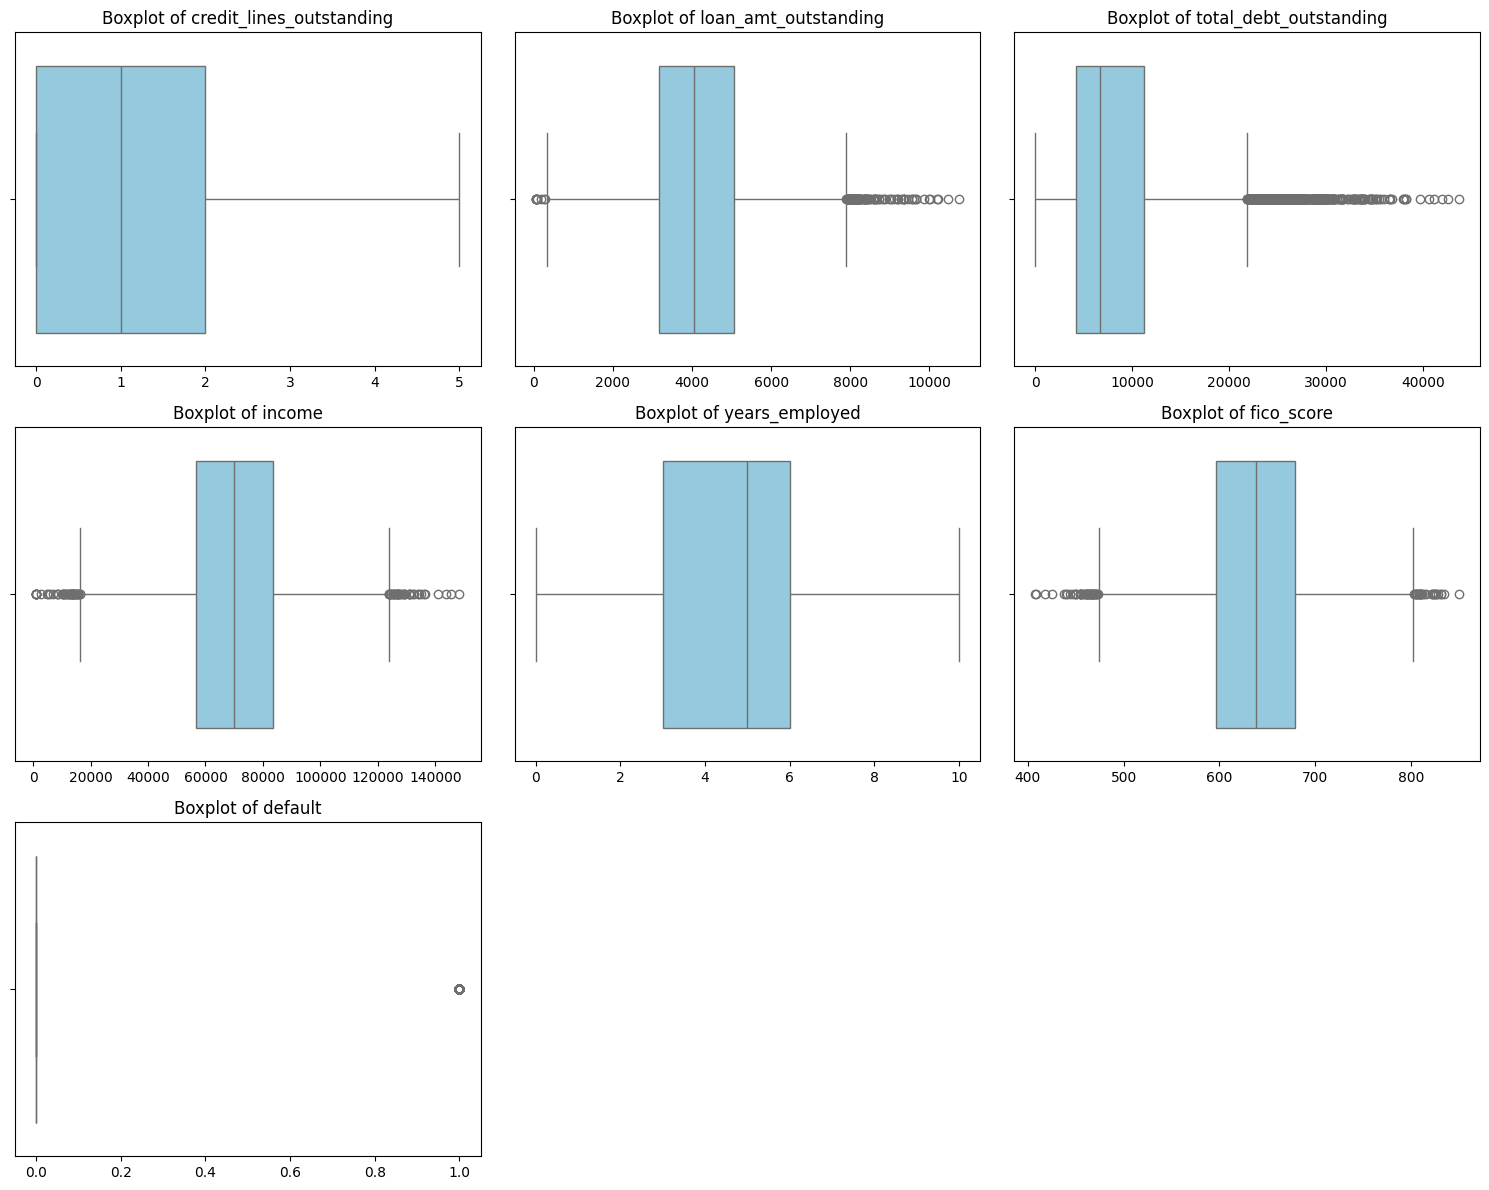

In [8]:
# visualisation graphique de la répartition des données pour les colonnes pertinentes

# 1. Sélection des colonnes pertinentes
df_boxplt = df.drop(columns=['customer_id'])
numerical_features = df_boxplt.columns
n_features = len(numerical_features)

# 2. Configuration de la grille (ex: 3 colonnes)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# 3. Création de la figure unique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # On aplatit le tableau d'axes pour boucler facilement

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('') # Optionnel : retire le label x pour plus de clarté

# 4. Supprimer les axes vides si le nombre de features n'est pas un multiple de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

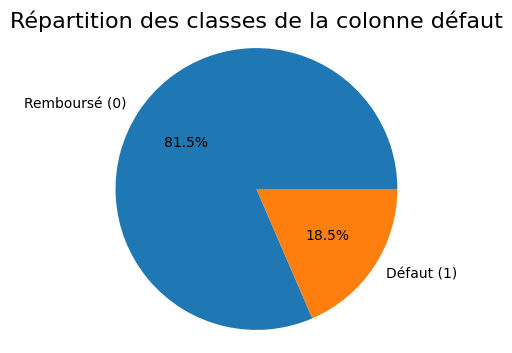

In [9]:
# Visualisation du déséquilibre de classe dans la colonne 'default'
# On suppose que ton DataFrame s'appelle 'df'
class_counts = df['default'].value_counts()

# 2. Personnalisation du graphique
labels = ['Remboursé (0)', 'Défaut (1)']
sizes = class_counts.values

# 3. Création du Pie Chart
plt.figure(figsize=(4, 4)) # Taille carrée pour un beau cercle
plt.pie(sizes, labels=labels,
        autopct='%1.1f%%')# Affiche le pourcentage avec une décimale

plt.title('Répartition des classes de la colonne défaut', fontsize=16)
plt.axis('equal')  # Garantit que le pie chart est bien un cercle

# 4. Affichage
plt.show()

**ANALYSE :**

On observe un déséquilibre de classe, avec une minorité de clients qui font défaut (18,5%). Ce déséquilibre est à garder en tête dans l'analyse des métriques d'évaluation des modèles de régression.

On observe que les colonnes 'total_debt_outstanding' et 'loan_amt_outstanding' présentent une asymétrie à droite, avec beaucoup de valeurs aberrantes à droite de leurs boxplot. On corrige cela en leur appliquant un log.

In [10]:
# Correction de l'asymétrie à droite avec un log
cols_to_log = ['total_debt_outstanding', 'loan_amt_outstanding']

for col in cols_to_log:
    df[col] = np.log1p(df[col])

df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,8.560740,8.272946,78039.38546,5,605,0
1,7442532,5,7.580663,9.015511,26648.43525,2,572,1
2,2256073,0,8.120889,7.615215,65866.71246,4,602,0
3,4885975,0,8.469608,7.825138,74356.88347,5,612,0
4,4700614,1,7.205507,7.478637,23448.32631,6,631,0


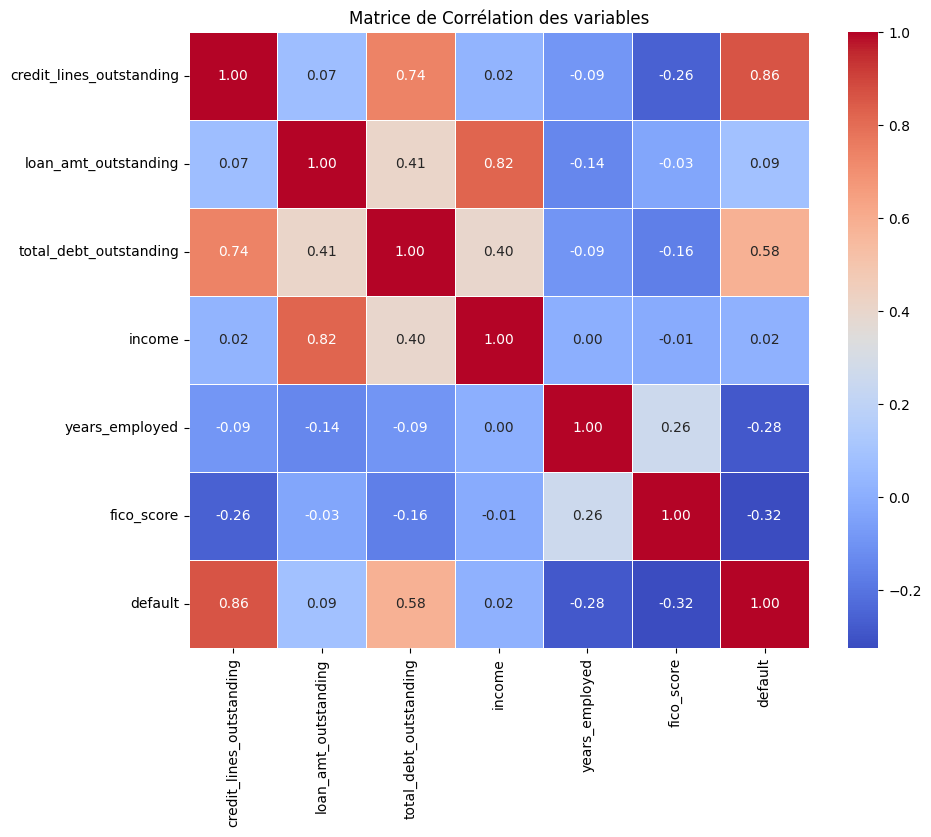

In [11]:
corr_matrix = df.drop(columns=['customer_id']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation des variables")
plt.show()

In [12]:
print(df.corr()["default"].sort_values(ascending=False))

default                     1.000000
credit_lines_outstanding    0.862815
total_debt_outstanding      0.583025
loan_amt_outstanding        0.087450
income                      0.016309
customer_id                 0.006927
years_employed             -0.284506
fico_score                 -0.324515
Name: default, dtype: float64


**ANALYSE :**

D'après la matrice de corrélation, les deux principales variables à étudier pour prévoir le défaut d'un client seraient : 
- la 'credit_line_outstanding' (0.86) ;
- le 'total_debt_outstanding' (0,58). 

Ainsi, plus le client est globalement endetté, plus il aura tendance à faire défaut. 

On note cependant un *risque de fuite de données* avec le 'credit_line_outstanding'. En effet, s'il s'agit des données au moment du défaut du client, elles ne seront pas disponibles au moment de la contraction du prêt. 

Le 'fico_score', qui semble tout indiqué pour étudier la propension d'un client à faire défaut, n'arrive nénamoins qu'en troisième place (-0,32). Il présente de même un score négatif, ce qui ne le fait visuellement pas ressortir comme un facteur très prédictif du défaut. Un fico-score plus élevé, plus proche de 800, est en effet indicateur d'une plus grande fiabilité du client. 

Comme l'intuition le laisse deviner, l'ancienneté dans l'emploi actuel est une autre variable négativement corrélée au risque de défaut (-0.28). Plus on est stable dans son emploi, moins on risque de faire défaut. 

Enfin, on observe une quasi-absence d'influence de la part d'autres facteurs, comme le nombre de crédits contractés, ou du salaire. 

Vues les subtilités révélées par la matrice de corrélation, il semble en effet pertinent de mettre en place un modèle de régression pour étudier le risque de défaut. 

# Choix des variables et division train/test

On supprime des variables explicatives 'default' (notre colonne de prédiction), 'customer_id' (qui ne possède pas de lien avec le risque de défaut) et 'credit_line_outstanding' (contre le risque de fuite de données).

In [71]:
X_raw = df.drop(columns=['default', 'customer_id', "credit_lines_outstanding"])
y = df['default']

In [61]:
def feature_engineering(X):
    X = X.copy()
    X["dti"] = np.log(X["total_debt_outstanding"]) / X["income"]
    X["lti"] = np.log(X["loan_amt_outstanding"])   / X["income"]
    return X[["income", "years_employed", "fico_score", "dti", "lti"]]

preprocessor = Pipeline([
    ("features", FunctionTransformer(feature_engineering))
])

# Fit sur X_raw (obligatoire même si FunctionTransformer n'apprend rien)
X = preprocessor.fit_transform(X_raw)
print(X)

           income  years_employed  fico_score       dti       lti
0     78039.38546               5         605  0.000027  0.000028
1     26648.43525               2         572  0.000083  0.000076
2     65866.71246               4         602  0.000031  0.000032
3     74356.88347               5         612  0.000028  0.000029
4     23448.32631               6         631  0.000086  0.000084
...           ...             ...         ...       ...       ...
9995  42691.62787               5         697  0.000048  0.000049
9996  79969.50521               8         615  0.000027  0.000027
9997  38192.67591               5         596  0.000056  0.000055
9998  50929.37206               2         647  0.000038  0.000041
9999  30611.62821               6         757  0.000068  0.000066

[10000 rows x 5 columns]


In [62]:
#Ajout de stratify pour compenser the class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [63]:
print(y_train.value_counts(normalize=True))

default
0    0.814875
1    0.185125
Name: proportion, dtype: float64


In [64]:
#Scaler pour regression logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Définition et entraînement des modèles

## Définition des modèles

In [72]:
## Models definition 

#--- Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.01,  # commence avec une régularisation assez forte
    penalty='l2',
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train)

#--- Decision Tree
# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5], # None = l'arbre pousse jusqu'au bout - overfitting
    'min_samples_split': [20, 50],
    'min_samples_leaf': [20, 50],
    'class_weight': ['balanced']
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc', # roc_auc pour dataset déséquilibré
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

#--- Random Forest
# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [3, 5],          # Profondeur de chaque arbre
    'min_samples_leaf': [20, 50],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False],
    'class_weight': ['balanced']            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_


#XGBoost 

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train)
best_xgb = xgb.best_estimator_

/Users/roseaupepin/Documents/DU_data/MLops/projet final MLops/creditloanprediction copy/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Entraînement des modèles

In [66]:
# On récupère le chemin absolu du dossier actuel
current_dir = os.getcwd()
db_path = os.path.join(current_dir, "mlflow.db")

# On force l'utilisation de ce fichier précis
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("credit-loan-prediction")

<Experiment: artifact_location=('/Users/roseaupepin/Documents/DU_data/MLops/projet final '
 'MLops/creditloanprediction/mlruns/1'), creation_time=1775430832802, experiment_id='1', last_update_time=1775430832802, lifecycle_stage='active', name='credit-loan-prediction', tags={}, workspace='default'>

In [67]:
# Engistrement de la pipeline de transformation de données

with mlflow.start_run(run_name="preprocessor"):
    mlflow.sklearn.log_model(
        preprocessor,
        name="preprocessor",
        registered_model_name="credit_loan_preprocessor"
    )
    print("Preprocessor enregistré.")

2026/04/06 16:19:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 16:19:52 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/06 16:19:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Preprocessor enregistré.


Registered model 'credit_loan_preprocessor' already exists. Creating a new version of this model...
Created version '3' of model 'credit_loan_preprocessor'.


In [68]:
# Engistrement des modèles dans mlflow pour comparaison

models = {
    "LogisticRegression": lr,
    "DecisionTree": best_dt,
    "RandomForest": best_rf,
    "XGB":xgb
}


for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        
        X_eval = X_test_scaled if model_name == "LogisticRegression" else X_test

        y_pred = model.predict(X_eval)
        probas = model.predict_proba(X_eval)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)

        mlflow.log_metric("accuracy",        report["accuracy"])
        mlflow.log_metric("f1_class_1",      report["1"]["f1-score"])
        mlflow.log_metric("recall_class_1",  report["1"]["recall"])
        mlflow.log_metric("precision_class_1", report["1"]["precision"])
        mlflow.log_metric("roc_auc",         roc_auc_score(y_test, probas))

        model_info = mlflow.sklearn.log_model(
            model, 
            name=model_name,
            registered_model_name=model_name
        )

        # Staging
        client = mlflow.tracking.MlflowClient()
        latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
        client.transition_model_version_stage(
            name=model_name,
            version=latest_version,
            stage="Staging"
        )
        print(f"Modèle '{model_name}' v{latest_version} → Staging")


2026/04/06 16:19:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 16:20:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'LogisticRegression' already exists. Creating a new version of this model...
Created version '2' of model 'LogisticRegression'.
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the dep

Modèle 'LogisticRegression' v2 → Staging


2026/04/06 16:20:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'DecisionTree' already exists. Creating a new version of this model...
Created version '2' of model 'DecisionTree'.
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/1545787789.py:35: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 

Modèle 'DecisionTree' v2 → Staging


2026/04/06 16:20:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'RandomForest' already exists. Creating a new version of this model...
Created version '2' of model 'RandomForest'.
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/1545787789.py:35: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 

Modèle 'RandomForest' v2 → Staging


2026/04/06 16:20:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modèle 'XGB' v2 → Staging


Registered model 'XGB' already exists. Creating a new version of this model...
Created version '2' of model 'XGB'.
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/1545787789.py:34: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/1545787789.py:35: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/

## Enregistrement du meilleur modèle

In [ ]:
# Trouver le meilleur run basé sur roc_auc
runs = mlflow.search_runs(
    experiment_names=["credit-loan-prediction"],
    order_by=["start_time DESC"]
)

# Garder les 4 derniers puis trier par roc_auc
best_run = runs.head(4).sort_values("metrics.roc_auc", ascending=False).iloc[0]

print(f"Meilleur modèle : {best_run['tags.mlflow.runName']}")
print(f"F1 score : {best_run['metrics.f1_class_1']:.4f}")
print(f"Accuracy : {best_run['metrics.accuracy']:.4f}")

# Enregistrer le meilleur modèle dans le Model Registry
best_run_id = best_run["run_id"]
model_name = best_run["tags.mlflow.runName"]

mlflow.register_model(
    model_uri=f"runs:/{best_run_id}/{model_name}",
    name="best_credit_loan_model"
)

# Laisser le temps au registry d'enregistrer
time.sleep(2)

client = mlflow.tracking.MlflowClient()

latest_version = client.get_latest_versions("best_credit_loan_model", stages=["None"])[0].version

# Passer en Production
client.transition_model_version_stage(
    name="best_credit_loan_model",
    version=latest_version,
    stage="Production"
)


print(f"Meilleur modèle '{model_name}' passé en production.")

Registered model 'best_credit_loan_model' already exists. Creating a new version of this model...
2026/04/06 16:20:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 2a5fa870a9cf4204ab3eac6bf4cdf584 has no artifacts at artifact path 'RandomForest', registering model based on models:/m-4ffb09c002804539a4fab326e4615b1d instead


Meilleur modèle : RandomForest
F1 score : 0.4895
Accuracy : 0.7445


Created version '5' of model 'best_credit_loan_model'.


Meilleur modèle 'RandomForest' passé en production.


/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/359894899.py:30: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions("best_credit_loan_model", stages=["None"])[0].version
/var/folders/qr/dqrgsnz90cq9g_7jbznfnk9w0000gn/T/ipykernel_14460/359894899.py:33: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


### Vérification des probabilités de chaque modèle

In [70]:
model = lr
probas = model.predict_proba(X_test_scaled)[:, 1]
print(f"Echantillon des probabilités du modèle de régression logistique : \n {probas[:20]}")

Echantillon des probabilités du modèle de régression logistique : 
 [0.10337632 0.10576913 0.45473262 0.31473953 0.45782547 0.27676019
 0.35795973 0.72090522 0.06321853 0.58023454 0.71942047 0.07798095
 0.45466467 0.31421534 0.249005   0.66879268 0.52736044 0.50255019
 0.54945405 0.1983461 ]


In [40]:
model = best_dt
probas = model.predict_proba(X_test)[:, 1]
print(f"Echantillon des probabilités du modèle d'arbre de décision : \n {probas[:20]}")

Echantillon des probabilités du modèle d'arbre de décision : 
 [0.09160447 0.09160447 0.21297008 0.16362336 0.60661149 0.34397547
 0.34397547 0.70557224 0.09160447 0.37297464 0.83372612 0.09160447
 0.21297008 0.34397547 0.34397547 0.70557224 0.60661149 0.4285959
 0.60661149 0.17912124]


In [ ]:
print(grid_search_rf.best_params_)
print("Train:", grid_search_rf.score(X_train, y_train))
print("Test: ", grid_search_rf.score(X_test, y_test))

{'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 100}
Train: 0.910617994106253
Test:  0.8954418836013929


In [75]:
model = best_xgb
probas = model.predict_proba(X_test_scaled)[:, 1]
print(f"Echantillon des probabilités du modèle XGBoost : \n {probas[:20]}")

Echantillon des probabilités du modèle XGBoost : 
 [4.1945133e-04 3.1405482e-03 1.4349414e-02 4.8219818e-03 1.8620687e-02
 6.2834457e-02 8.0707902e-03 8.4940994e-01 4.0425599e-04 5.3047827e-03
 7.5036353e-03 2.0210990e-03 3.4502361e-03 6.6125230e-03 1.4569486e-03
 4.6190466e-03 2.0944516e-01 2.6143207e-03 6.3079342e-02 3.1198816e-02]


### Feature importance 
#TODO : améliorer cette partie

In [42]:
from sklearn.inspection import permutation_importance

result = permutation_importance(grid_search_rf.best_estimator_, X_test, y_test, n_repeats=10)
for i, col in enumerate(X.columns):
    print(f"{col}: {result.importances_mean[i]:.4f}")

income: -0.0024
years_employed: 0.0540
fico_score: 0.0495
dti: 0.0188
lti: -0.0035


# Archive : étude de chaque modèle séparé
#TODO : à réintégrer ou supprimer

**1 - Logistic Regression**

In [46]:
#Training Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)


print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      1630
           1       0.78      0.27      0.40       370

    accuracy                           0.85      2000
   macro avg       0.82      0.63      0.66      2000
weighted avg       0.84      0.85      0.82      2000



In [47]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.01,  # commence avec une régularisation assez forte
    penalty='l2',
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)

# Évaluation
y_pred = lr.predict(X_test_scaled)
probas = lr.predict_proba(X_test_scaled)[:, 1]
print(probas[:20])
print(classification_report(y_test, y_pred))

[0.10337632 0.10576913 0.45473262 0.31473953 0.45782547 0.27676019
 0.35795973 0.72090522 0.06321853 0.58023454 0.71942047 0.07798095
 0.45466467 0.31421534 0.249005   0.66879268 0.52736044 0.50255019
 0.54945405 0.1983461 ]
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1630
           1       0.36      0.71      0.48       370

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.64      2000
weighted avg       0.81      0.71      0.74      2000



/Users/roseaupepin/Documents/DU_data/MLops/projet final MLops/creditloanprediction copy/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [48]:
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
print(importance.sort_values(by='Coefficient', ascending=False))

          Feature  Coefficient
3             dti    14.856762
0          income    -0.196880
1  years_employed    -0.688398
2      fico_score    -0.735971
4             lti   -15.935893


# Decision Tree

In [49]:
# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None], # None = l'arbre pousse jusqu'au bout
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1', # On optimise le F1-score car le défaut est une classe sensible
    n_jobs=-1
)

# 3. Entraînement
grid_search_dt.fit(X_train, y_train)

# 4. Affichage des meilleurs paramètres
print("Meilleurs paramètres Arbre :", grid_search_dt.best_params_)

# 5. Évaluation du meilleur modèle
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("\nReport de l'Arbre Optimisé :")
print(classification_report(y_test, y_pred_best_dt))

Meilleurs paramètres Arbre : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}

Report de l'Arbre Optimisé :
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1630
           1       0.68      0.61      0.65       370

    accuracy                           0.88      2000
   macro avg       0.80      0.77      0.79      2000
weighted avg       0.87      0.88      0.87      2000



# Random Forest

In [73]:
# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [10, 20, None],          # Profondeur de chaque arbre
    'min_samples_leaf': [1, 2, 4],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False]            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Entraînement
grid_search_rf.fit(X_train, y_train)

# 4. Résultats
print("Meilleurs paramètres Random Forest :", grid_search_rf.best_params_)

# 5. Évaluation finale
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nReport du Random Forest Optimisé :")
print(classification_report(y_test, y_pred_rf))

Meilleurs paramètres Random Forest : {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

Report du Random Forest Optimisé :
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1630
           1       0.86      0.61      0.71       370

    accuracy                           0.91      2000
   macro avg       0.89      0.79      0.83      2000
weighted avg       0.91      0.91      0.90      2000



In [74]:
# Récupérer l'importance des variables du Random Forest
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Récupérer les coefficients de la Régression Logistique (en valeur absolue pour comparer l'impact)
log_importances = pd.Series(abs(log_reg.coef_[0]), index=X.columns).sort_values(ascending=False)

print("TOP FEATURES - Random Forest:\n", rf_importances)
print("\nTOP FEATURES - LogReg:\n", log_importances)

TOP FEATURES - Random Forest:
 dti               0.295545
income            0.233209
fico_score        0.221390
lti               0.156408
years_employed    0.093449
dtype: float64

TOP FEATURES - LogReg:
 lti               15.935893
dti               14.856762
fico_score         0.735971
years_employed     0.688398
income             0.196880
dtype: float64


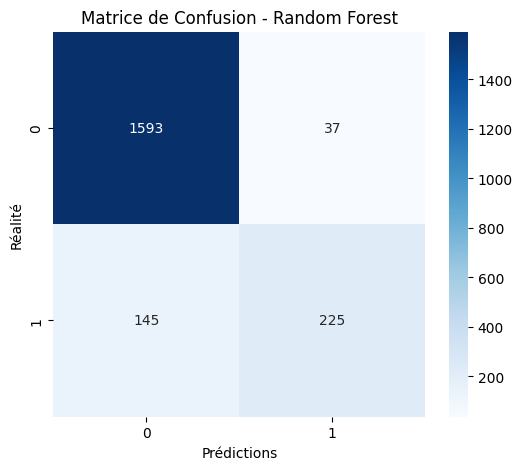

In [53]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

In [54]:
# Save the Random Forest model
os.makedirs('models', exist_ok=True)  
joblib.dump(best_rf, 'models/credit_risk_model_rf.pkl')

# Save the scaler (in case you need it for LogReg later)
joblib.dump(scaler, 'models/scaler_credit.pkl')

print("Models saved successfully!")

Models saved successfully!


# XGBoost

Le XGBoost est un Random Forest qui va entraîner ses arbres les uns après les autres, et pas en parallèle, ce qui lui permet de les améliorer au fur et à mesure.

Contrairement au Gradient Boosting classique, l'Extreme Gradient Boosting possède aussi des paramètres de régularisation intégrés, ce qui évite le surapprentissage.

In [44]:
# 1. Grille de paramètres pour XGBoost
# On teste la vitesse d'apprentissage, la profondeur et la proportion de données utilisées
param_grid_xgb_1 = {
    'n_estimators': [100, 200],           # Nombre d'arbres (itérations de boosting)
    'learning_rate': [0.01, 0.1, 0.2],    # Pas de progression (plus c'est bas, plus c'est robuste)
    'max_depth': [3, 5, 7],               # Profondeur des arbres (souvent plus faible que RF)
    'subsample': [0.8, 1.0],              # % de données utilisées par arbre (évite l'overfitting)
    'colsample_bytree': [0.8, 1.0]        # % de colonnes utilisées par arbre
}


# 2. Configuration GridSearch
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb_1,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Entraînement ( XGBoost peut prendre les données Scalées ou non, 
# mais on utilise X_train_scaled pour être cohérente avec la Régression Logistique)
grid_search_xgb.fit(X_train_scaled, y_train)

# 4. Résultats
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)

# 5. Évaluation finale
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)

print("\nReport du XGBoost Optimisé :")
print(classification_report(y_test, y_pred_xgb))

Meilleurs paramètres XGBoost : {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Report du XGBoost Optimisé :
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1630
           1       0.91      0.87      0.89       370

    accuracy                           0.96      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.96      0.96      0.96      2000



In [55]:
# Récupérer l'importance des variables du XGBoost_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
xgb_importances_1 = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

# Récupérer les coefficients de la Régression Logistique (en valeur absolue pour comparer l'impact)
xbgb_log_importances_1 = pd.Series(abs(log_reg.coef_[0]), index=X.columns).sort_values(ascending=False)

print("\nTOP FEATURES - XGBoost:\n", xgb_importances_1, "\n")
print("TOP FEATURES - Random Forest:\n", rf_importances)
print("\nTOP FEATURES - LogReg:\n", log_importances)


TOP FEATURES - XGBoost:
 income            0.256889
years_employed    0.255905
dti               0.204739
fico_score        0.170952
lti               0.111515
dtype: float32 

TOP FEATURES - Random Forest:
 dti               0.295545
income            0.233209
fico_score        0.221390
lti               0.156408
years_employed    0.093449
dtype: float64

TOP FEATURES - LogReg:
 lti               15.935893
dti               14.856762
fico_score         0.735971
years_employed     0.688398
income             0.196880
dtype: float64


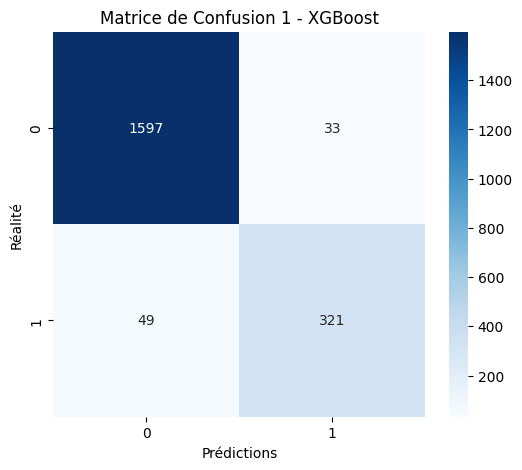

In [57]:
# matrice de confusion du XGBoost2
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion 1 - XGBoost')
plt.show()